### Imports

In [ ]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from extraction_1D import run_1d_pipeline
from skimage.feature import hog

### STEP 1: load CSD image, SVM model and json labels

In [2]:

# 1. setup paths 
# SVM model, go up one level with '../'
MODEL_PATH = "../classifier_training/svm_model.pkl"

# new images and labels are right in this folder
IMG_DIR = "csd_images"
LBL_DIR = "csd_labels"

# first test image 
TEST_IMAGE_NAME = "navtest_001_alpha0.251_wobble19.4.png" 
TEST_JSON_NAME = TEST_IMAGE_NAME.replace(".png", ".json")

# 2. load the Trained SVM Pipeline
with open(MODEL_PATH, "rb") as f:
    pipeline = pickle.load(f)
print("YES: SVM Pipeline loaded successfully.")

# 3. load the Test Image & Convert to Grayscale
# its a must toprocess the image EXACTLY how the SVM was trained
def load_image_gray(path: str) -> np.ndarray:
    img = plt.imread(path)
    if img.ndim == 3:
        # Collapse RGBA to luminance 
        gray = 0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]
    else:
        gray = img.astype(np.float32)
    return gray.astype(np.float32)

img_path = os.path.join(IMG_DIR, TEST_IMAGE_NAME)
img = load_image_gray(img_path)
print(f"YES: Loaded test image: {TEST_IMAGE_NAME} (Shape: {img.shape})")

# 4. load the Ground Truth (1,1) Coordinates from JSON
json_path = os.path.join(LBL_DIR, TEST_JSON_NAME)

with open(json_path, "r") as f:
    data = json.load(f)
    
true_target = data.get("target_pixel")
if true_target:
    true_x = true_target["col_px"]
    true_y = true_target["row_px"]
    print(f"YES: Ground Truth (1,1) Target is at: X={true_x}, Y={true_y}")
else:
    print("NO: Warning: No (1,1) target found in this JSON.")

YES: SVM Pipeline loaded successfully.
YES: Loaded test image: navtest_001_alpha0.251_wobble19.4.png (Shape: (500, 500))
YES: Ground Truth (1,1) Target is at: X=299, Y=199


### STEP 2: Run 1D extraction on the CSD and extract the matrix 

Detected row peaks: 5
Detected col peaks: 5
Total detected points from multi-slice: 551
Inliers: 86 / 551
Slope: 0.2711
~~~~~~~~~~ PASS 1: Diagonal Lines ~~~~~~~~~~~~~
Found diagonal line with 93 points (slope: 0.27)
Found diagonal line with 91 points (slope: 0.28)
Found diagonal line with 79 points (slope: 0.26)

~~~~~~~~~~ PASS 2: Steep Lines ~~~~~~~~~~~~~
Found steep line with 72 points (slope: 3.58)
Found steep line with 68 points (slope: 3.67)

Total lines found: 5


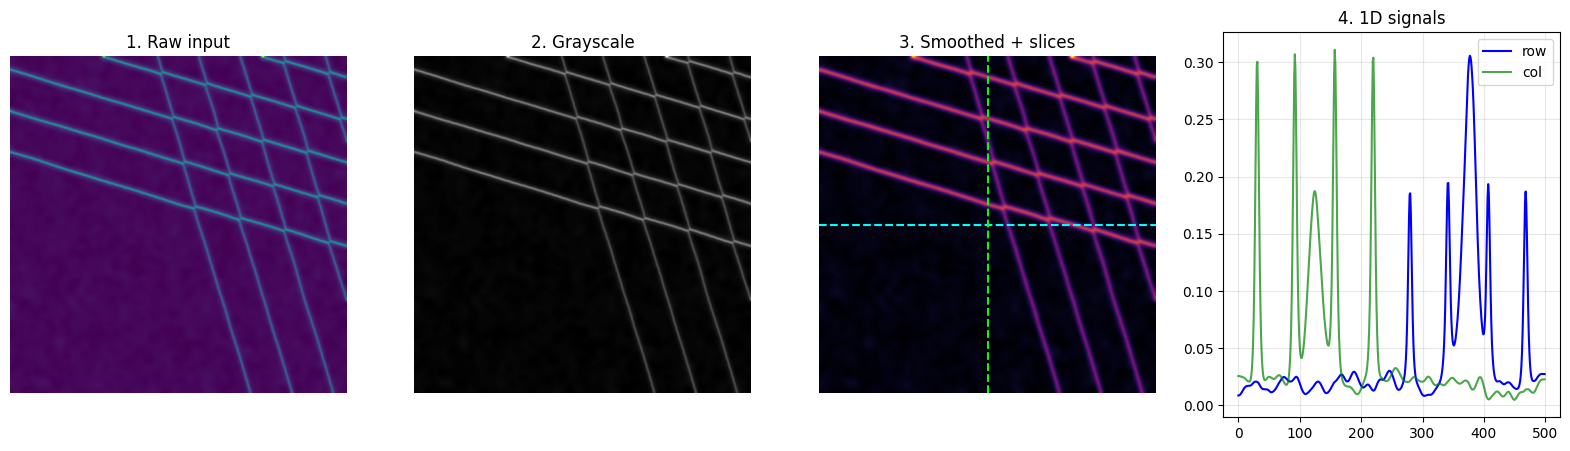

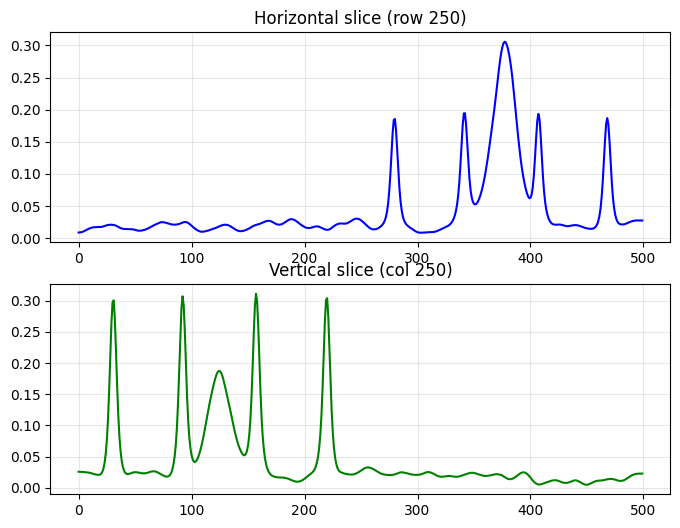

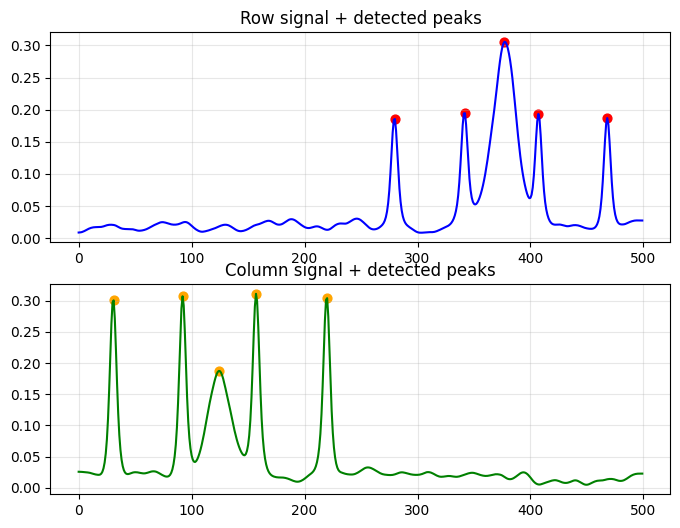

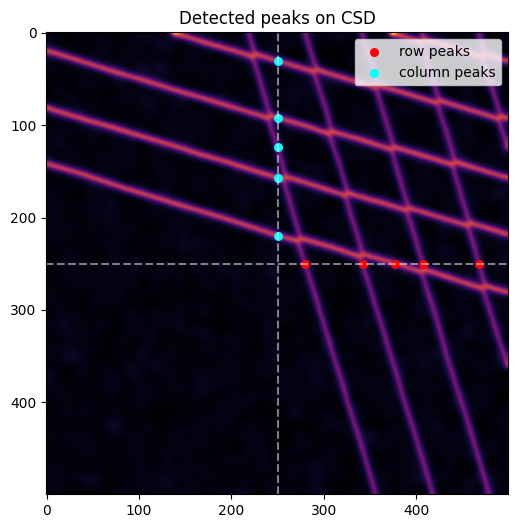

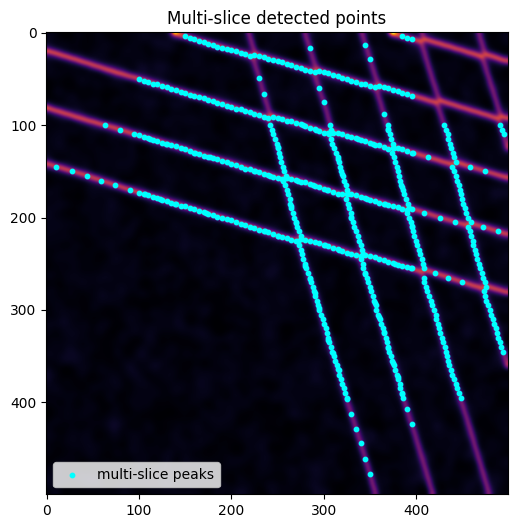

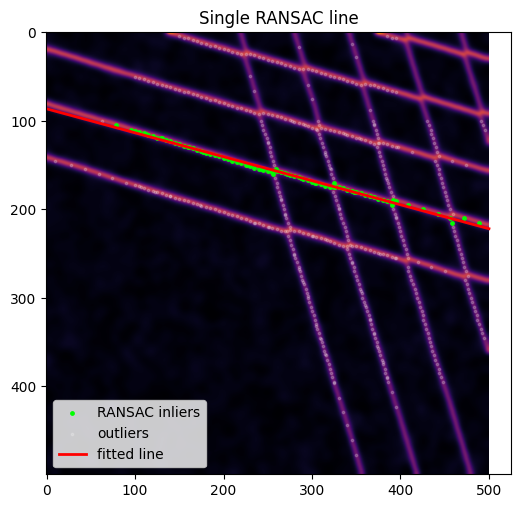

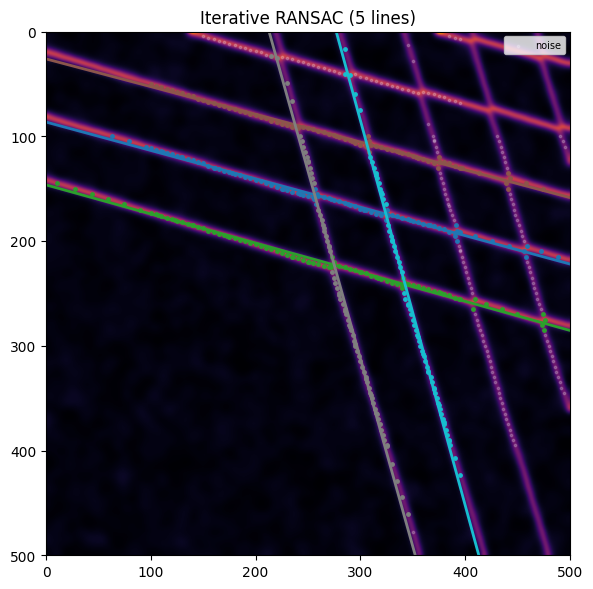

Saved iterative RANSAC result
Diagonal lines: 3
Steep lines: 2


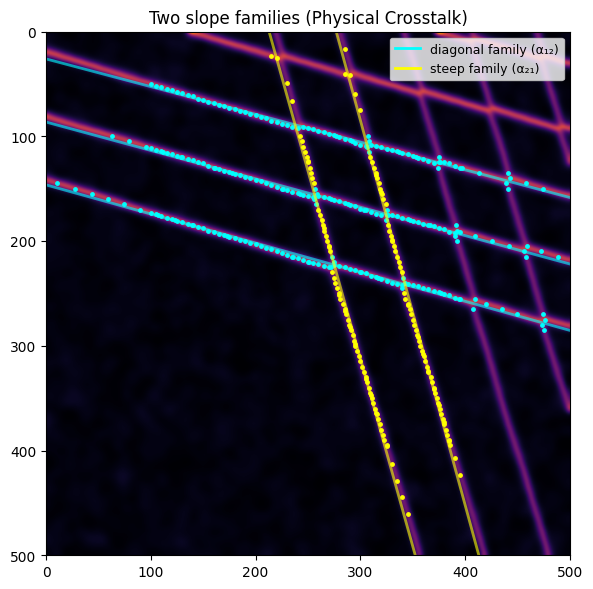

Displayed two slope families visualization with custom legend

Final extracted lines:
diagonal | slope = 0.2710 | points = 93
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.5829 | points = 72
steep    | slope = 3.6731 | points = 68

Filtered lines:
diagonal | slope = 0.2710 | points = 93
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.5829 | points = 72
steep    | slope = 3.6731 | points = 68
Rejected 0 outlier lines thru MAD.


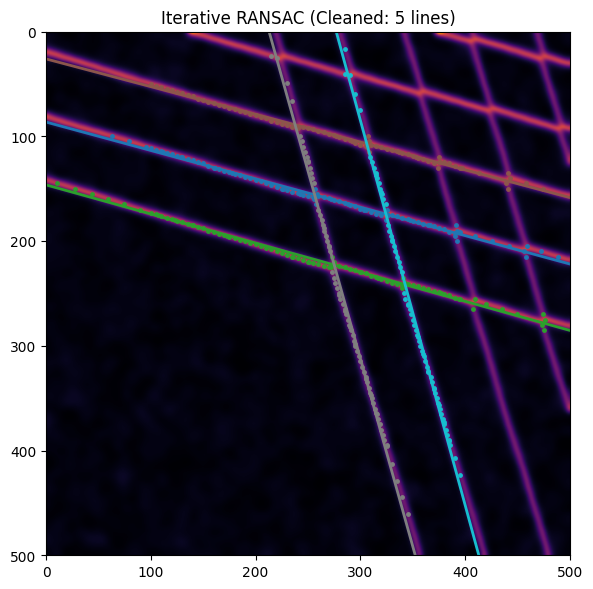

Displayed regenerated clean iterative RANSAC plot

FINAL RESULTS:
Diagonal slope (mean): 0.2711
Diagonal std: 0.0054
Steep slope (mean): 3.6280
Steep std: 0.0451
Slope ratio (s2/s1 = α21/α12 product ): 13.38
   diagonal α ≈ 0.2711  (input Cgd crosstalk was 0.25)
   steep α    ≈ 0.2756  (expected ~0.25 from symmetry)
1D Feature Extraction Complete!!!!!

 Navigation Vectors Acquired.
   v1 (Diagonal Step): [0.9652, 0.2617]
   v2 (Steep Step):    [0.2657, 0.9640]


In [3]:
# pass 'img' (from Cell 1) into the function
M, m1, m2, v1, v2, lines = run_1d_pipeline(img)

print(f"\n Navigation Vectors Acquired.")
print(f"   v1 (Diagonal Step): [{v1[0]:.4f}, {v1[1]:.4f}]")
print(f"   v2 (Steep Step):    [{v2[0]:.4f}, {v2[1]:.4f}]")



### STEP 3: Geometric jump and SVM verification

The CSD is slanted. If navigator wants to move from empty state to (1,1), it can't just move diagonally bc of cross-capacitance. So, this step creates some points over the image where the navigator can ofc "navigate" to. 

In [11]:
def extract_hog(patch):
    return hog(patch, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), visualize=False)

half = 42
h, w = img.shape

# find intersections of diagonal and steep lines
diag_lines  = [l for l in lines if l["type"] == "diagonal"]
steep_lines = [l for l in lines if l["type"] == "steep"]

intersections = []
for d in diag_lines:
    for s in steep_lines:
        md, bd = d["slope"], d["intercept"]
        ms, bs = s["slope"], s["intercept"]
        denom = md - ms
        if abs(denom) < 1e-6:
            continue
        x = (bs - bd) / denom
        y = md * x + bd
        if 0 <= x <= w and 0 <= y <= h:
            intersections.append((x, y))

# sort by distance from bottom-left — closest = lowest charge state region
intersections.sort(key=lambda p: np.sqrt(p[0]**2 + (p[1] - h)**2))

# center of 4 closest intersections = (1,1) center
bottom_4 = intersections[:4]
pred_x   = np.mean([p[0] for p in bottom_4])
pred_y   = np.mean([p[1] for p in bottom_4])
print(f"Found {len(intersections)} intersections")
print(f"Predicted (1,1) center : ({pred_x:.1f}, {pred_y:.1f})")

# SVM Verification at predicted location
px, py   = int(pred_x), int(pred_y)
patch    = img[py-half:py+half+1, px-half:px+half+1]
features = extract_hog(patch).reshape(1, -1)
feat_sc  = pipeline[:-1].transform(features)
score    = pipeline.named_steps["svm"].decision_function(feat_sc)[0]

THRESHOLD = -0.85
if score > THRESHOLD:
    print(f" (1,1) CONFIRMED at ({px}, {py})   SVM score={score:.4f}")
else:
    print(f"  Verification weak  at ({px}, {py})  SVM score={score:.4f}")

confirmed_x, confirmed_y = px, py
dist = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
print(f"Ground truth : ({true_x}, {true_y})")
print(f"Distance     : {dist:.1f} px")

Found 6 intersections
Predicted (1,1) center : (299.6, 198.7)
 (1,1) CONFIRMED at (299, 198)   SVM score=0.7518
Ground truth : (299, 199)
Distance     : 0.7 px


### STEP 4: State machine map

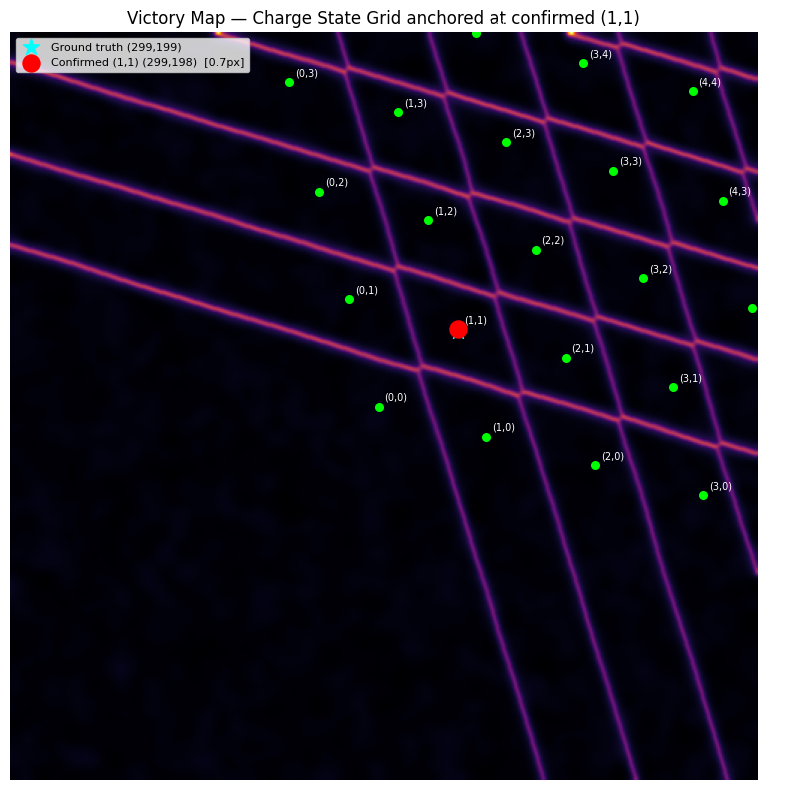

In [9]:
step_size = 75

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="inferno")

for i in range(-1, 5):
    for j in range(-1, 5):
        point = np.array([confirmed_x, confirmed_y]) + (i * step_size * v1) - (j * step_size * v2)
        x, y  = int(point[0]), int(point[1])
        if 0 <= x < w and 0 <= y < h:
            is_target = (i == 0 and j == 0)
            ax.scatter(x, y,
                       color="red" if is_target else "lime",
                       s=120 if is_target else 30, zorder=3)
            ax.text(x+4, y-4, f"({i+1},{j+1})", color="white", fontsize=7, zorder=4)

ax.scatter(true_x, true_y, color="cyan", s=150, marker="*", zorder=5,
           label=f"Ground truth ({true_x},{true_y})")
ax.scatter(confirmed_x, confirmed_y, color="red", s=150, zorder=5,
           label=f"Confirmed (1,1) ({confirmed_x},{confirmed_y})  [{dist:.1f}px]")

ax.legend(fontsize=8)
ax.set_title("Victory Map — Charge State Grid anchored at confirmed (1,1)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Just testing stuff. (not related)

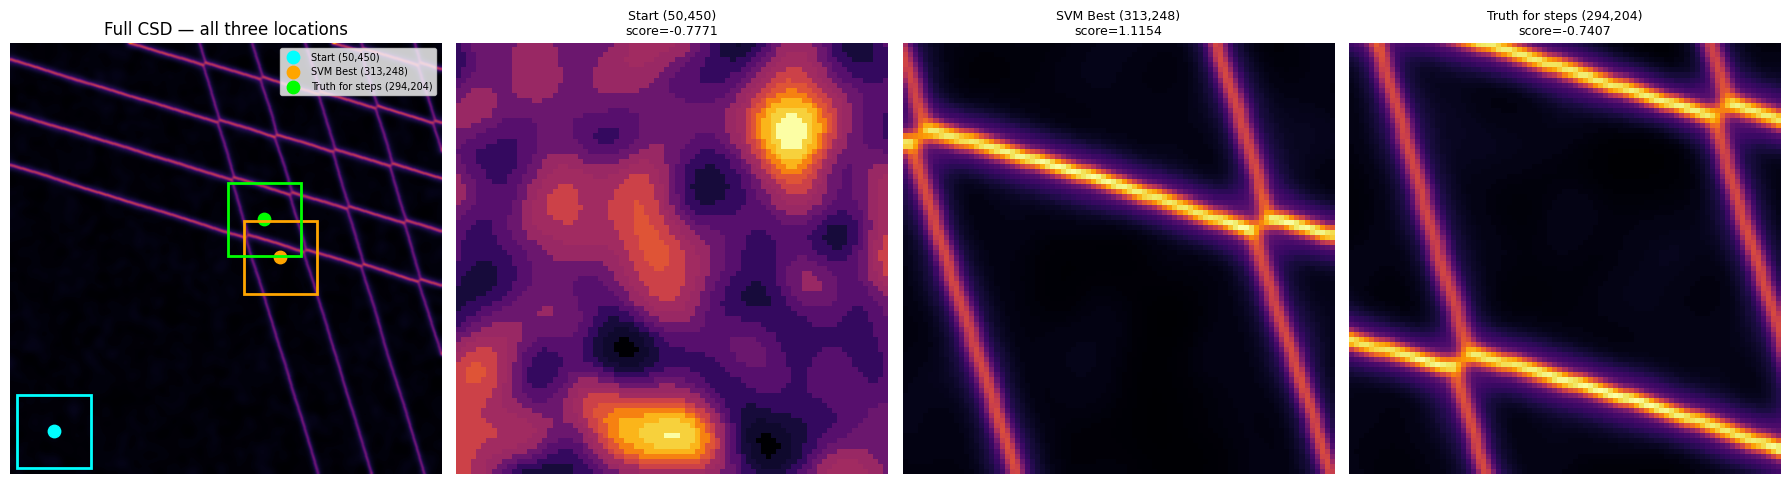

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

half = 42
patch_size = 85

# The three locations to inspect
locations = [
    ("Start (50,450)",          50,  450, "cyan"),
    ("SVM Best (313,248)",      313, 248, "orange"),
    ("Truth for steps (294,204)",  294, 204, "lime"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Left: full CSD with all three marked
ax = axes[0]
ax.imshow(img, cmap="inferno")
for label, cx, cy, color in locations:
    ax.scatter(cx, cy, color=color, s=80, zorder=3, label=label)
    rect = mpatches.Rectangle(
        (cx - half, cy - half), patch_size, patch_size,
        linewidth=2, edgecolor=color, facecolor="none", zorder=4)
    ax.add_patch(rect)
ax.legend(loc="upper right", fontsize=7)
ax.set_title("Full CSD — all three locations")
ax.axis("off")

# Right: one patch per location
for ax, (label, cx, cy, color) in zip(axes[1:], locations):
    patch = img[cy-half:cy+half+1, cx-half:cx+half+1]
    ax.imshow(patch, cmap="inferno")
    
    features = extract_hog(patch).reshape(1, -1)
    feat_sc  = pipeline[:-1].transform(features)
    score    = pipeline.named_steps["svm"].decision_function(feat_sc)[0]
    
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
    ax.set_title(f"{label}\nscore={score:.4f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()